## Bagian 1: Persiapan Data & Exploratory Data Analysis (EDA)
Menyiapkan *environment* lokal, memuat dataset, dan memastikan semua library pendukung telah siap.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import os

folder_path = '.' 

try:
    os.chdir(folder_path)
    print("Berhasil mengatur direktori lokal di:", os.path.abspath(os.getcwd()))

    if 'Bitcoin3.csv' in os.listdir():
        print("File Bitcoin3.csv siap digunakan.")
    else:
        print("File Bitcoin3.csv tidak ditemukan di direktori ini.")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")

Berhasil mengatur direktori lokal di: d:\Tugas Dicoding\ML\Proyek_Akhir
File Bitcoin3.csv siap digunakan.


### Exploratory Data Analysis (EDA)
Memenuhi kriteria **Basic** (Heatmap Korelasi untuk memilih minimal 3 fitur) dan **Skilled** (Analisis Dekomposisi target `Close`).

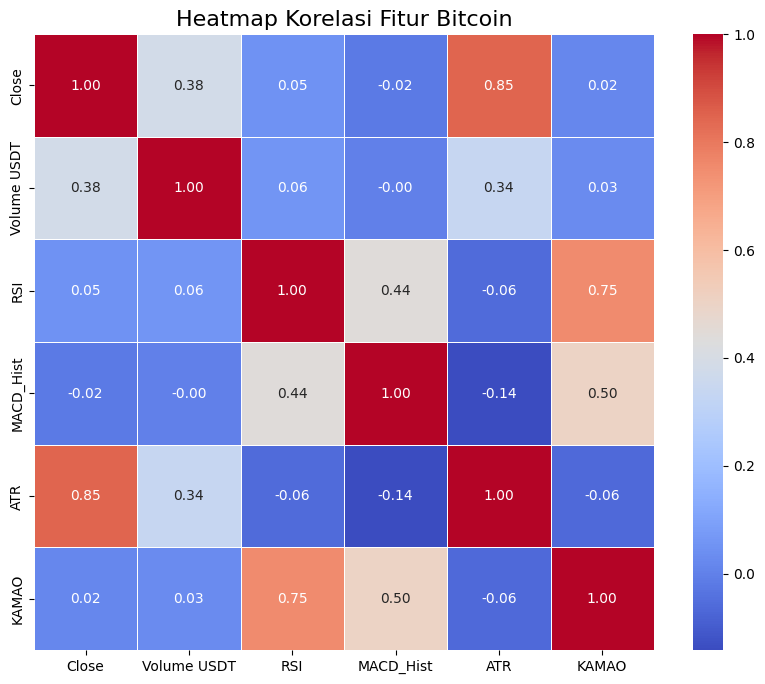

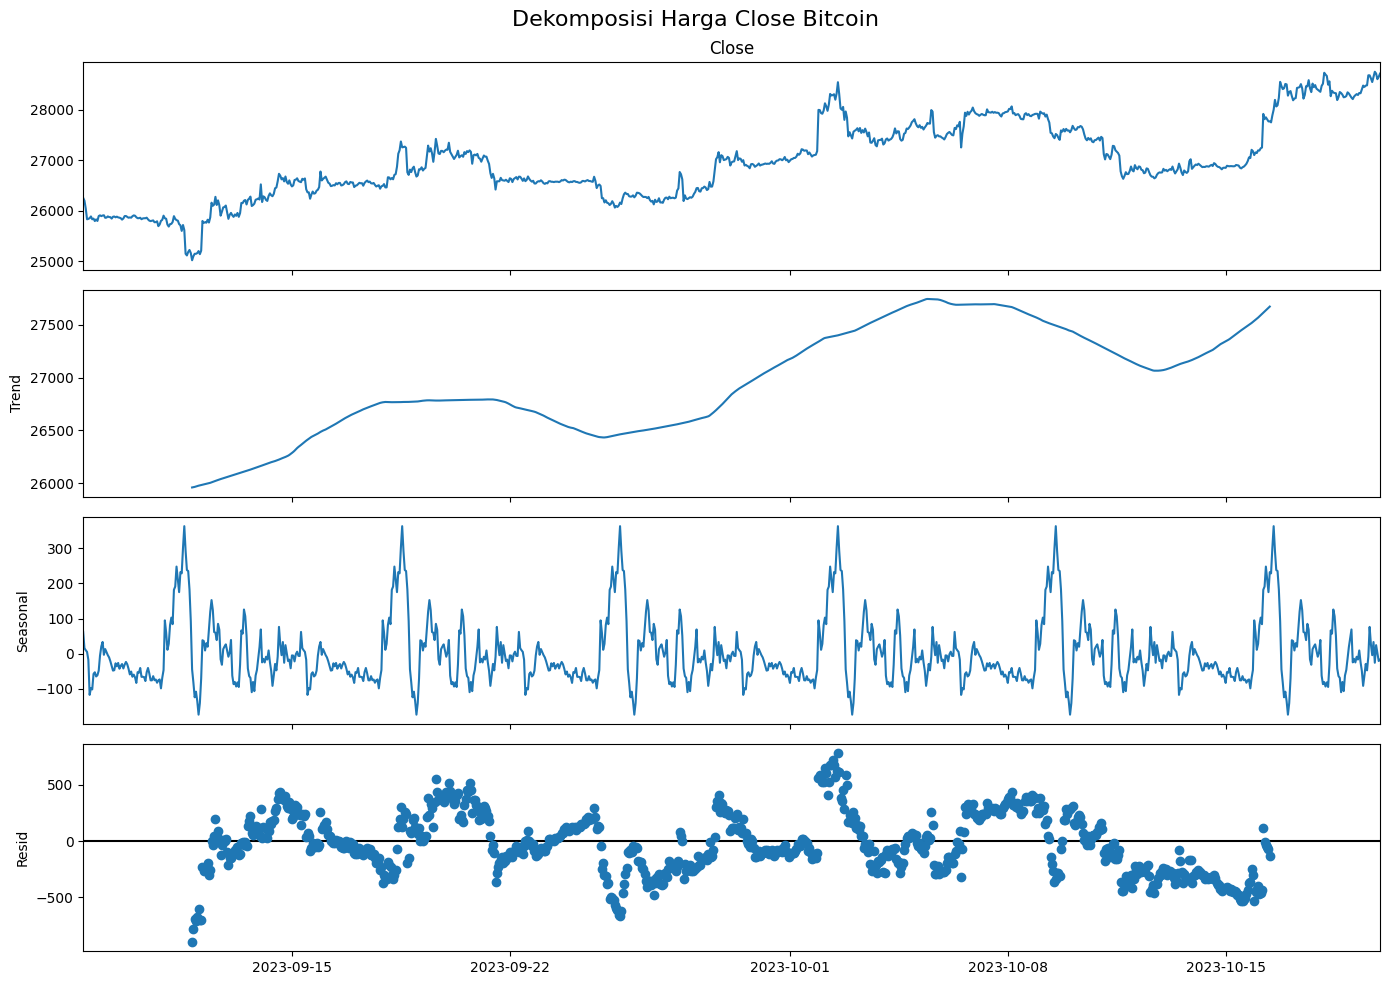

In [23]:
df = pd.read_csv('Bitcoin3.csv')
df['Date'] = pd.to_datetime(df['Date'], format='ISO8601')
df.set_index('Date', inplace=True)

plt.figure(figsize=(10, 8))
plt.title('Heatmap Korelasi Fitur Bitcoin', fontsize=16)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()
print("\n")

sample_data = df['Close'][-1000:] 
decomposition = seasonal_decompose(sample_data, model='additive', period=168)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Dekomposisi Harga Close Bitcoin', fontsize=16)
plt.tight_layout()
plt.show()

### Feature Engineering & Uji Analisis Lag
1. Menggunakan 4 fitur: `Close`, `ATR`, `Volume USDT`, `RSI`.
2. Menambahkan fitur `Rolling Statistics` (Mean & Std).
3. Melakukan Uji `ACF` dan `PACF` untuk validasi window size.
4. Menambahkan Cyclical Encoding (Sin/Cos jam) untuk kepekaan arsitektur Seq2Seq.

Fitur berhasil ditambah. Total fitur: 8


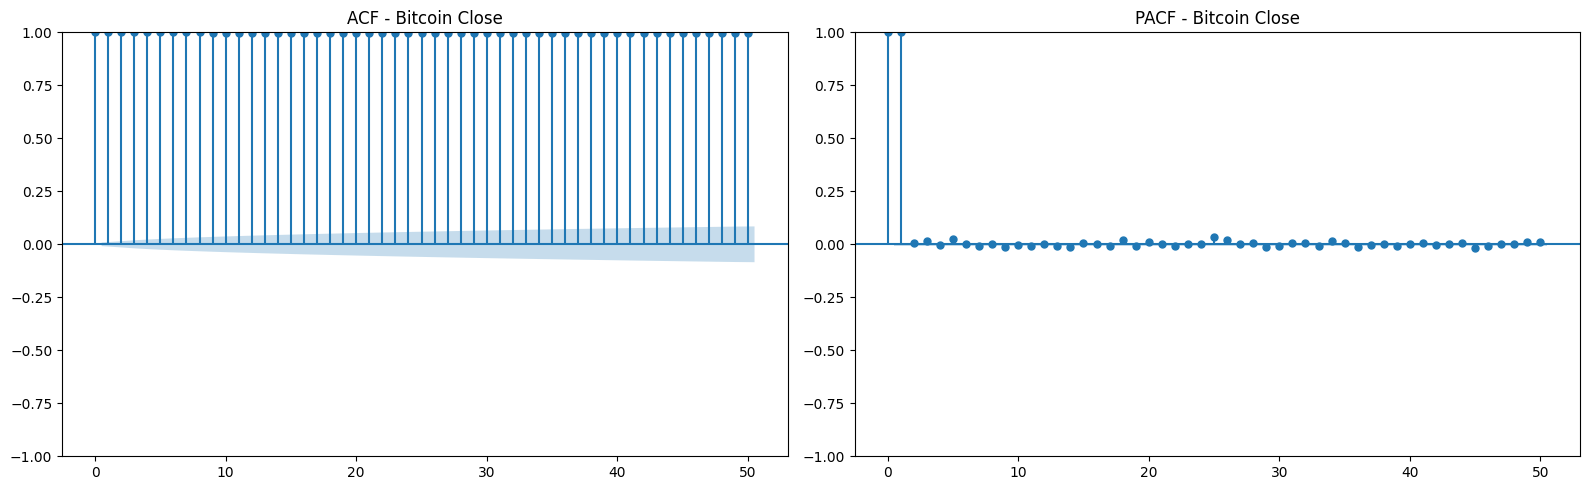

In [24]:
df_selected = df[['Close', 'ATR', 'Volume USDT', 'RSI']].copy()

df_selected['Rolling_Mean_Close_24h'] = df_selected['Close'].rolling(window=24).mean()
df_selected['Rolling_Std_Close_24h'] = df_selected['Close'].rolling(window=24).std()

hours_in_day = 24
hour_index = df_selected.index.hour
df_selected['Sin_Hour'] = np.sin(2 * np.pi * hour_index / hours_in_day)
df_selected['Cos_Hour'] = np.cos(2 * np.pi * hour_index / hours_in_day)

df_selected.dropna(inplace=True)
print("Fitur berhasil ditambah. Total fitur:", df_selected.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_selected['Close'], lags=50, ax=axes[0], title="ACF - Bitcoin Close")
plot_pacf(df_selected['Close'], lags=50, ax=axes[1], title="PACF - Bitcoin Close")
plt.tight_layout()
plt.show()

### Data Splitting & TF Dataset Pipeline
Menerapkan *Dual Scaling* untuk mencegah *Data Leakage* (hanya fit pada data latih) dan membungkus data ke dalam `tf.data.Dataset` untuk optimasi. Karena dieksekusi di CPU, *pipeline* ini sangat penting agar tidak membebani memori (RAM).

In [25]:
n = len(df_selected)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

train_df = df_selected[:train_size]
val_df = df_selected[train_size:train_size+val_size]
test_df = df_selected[train_size+val_size:]

target_scaler = MinMaxScaler()
train_target = target_scaler.fit_transform(train_df[['Close']]) 

full_scaler = MinMaxScaler()
train_scaled = full_scaler.fit_transform(train_df)
val_scaled = full_scaler.transform(val_df)
test_scaled = full_scaler.transform(test_df)

def create_sequences(data, window_size=24, horizon=24):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size : i + window_size + horizon, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_val, y_val = create_sequences(val_scaled)
X_test, y_test = create_sequences(test_scaled)

BATCH_SIZE = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Pipeline Data Siap!")
print(f"Dimensi X_train: {X_train.shape} -> (Batch, Time_Steps, Features)")
print(f"Dimensi y_train: {y_train.shape} -> (Batch, Horizon)")

Pipeline Data Siap!
Dimensi X_train: (37141, 24, 8) -> (Batch, Time_Steps, Features)
Dimensi y_train: (37141, 24) -> (Batch, Horizon)


## Bagian 2: Arsitektur Model Kustom

### Membuat Custom Layers
1. **CustomDense:** Membuat ulang operasi regresi linier murni (Bobot & Bias).
2. **CustomMultiHeadAttention:** Membuat ulang mekanisme atensi untuk menangkap hubungan fitur penting.
3. **CustomDropout:** Membuat ulang mekanisme *regularization* untuk mematikan neuron secara acak saat *training* (Mencegah *Overfitting*).

In [26]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="CustomDense")
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform", trainable=True, name="dense_weight")
        self.b = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True, name="dense_bias")

    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

@tf.keras.utils.register_keras_serializable(package="Custom", name="CustomMultiHeadAttention")
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim

    def build(self, input_shape):
        embed_dim = input_shape[0][-1] 
        self.Wq = self.add_weight(shape=(embed_dim, self.num_heads * self.key_dim), initializer="glorot_uniform", trainable=True)
        self.Wk = self.add_weight(shape=(embed_dim, self.num_heads * self.key_dim), initializer="glorot_uniform", trainable=True)
        self.Wv = self.add_weight(shape=(embed_dim, self.num_heads * self.key_dim), initializer="glorot_uniform", trainable=True)
        self.Wo = self.add_weight(shape=(self.num_heads * self.key_dim, embed_dim), initializer="glorot_uniform", trainable=True)

    def call(self, inputs):
        query, key, value = inputs[0], inputs[1], inputs[2]
        
        q = tf.matmul(query, self.Wq)
        k = tf.matmul(key, self.Wk)
        v = tf.matmul(value, self.Wv)

        def split_heads(x):
            seq_len = tf.shape(x)[1] 
            x = tf.reshape(x, (-1, seq_len, self.num_heads, self.key_dim))
            return tf.transpose(x, perm=[0, 2, 1, 3])

        q = split_heads(q)
        k = split_heads(k)
        v = split_heads(v)
        
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(tf.cast(self.key_dim, tf.float32))
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        
        output = tf.transpose(tf.matmul(attention_weights, v), perm=[0, 2, 1, 3])
        
        seq_len_q = tf.shape(query)[1]
        concat_attention = tf.reshape(output, (-1, seq_len_q, self.num_heads * self.key_dim))
        
        final_out = tf.matmul(concat_attention, self.Wo)
        final_out.set_shape(query.shape)
        return final_out

    def get_config(self):
        config = super().get_config()
        config.update({"num_heads": self.num_heads, "key_dim": self.key_dim})
        return config

@tf.keras.utils.register_keras_serializable(package="Custom", name="CustomDropout")
class CustomDropout(tf.keras.layers.Layer):
    def __init__(self, rate, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training:
            out = tf.nn.dropout(inputs, rate=self.rate)
        else:
            out = inputs
        out.set_shape(inputs.shape)
        return out

    def get_config(self):
        config = super().get_config()
        config.update({"rate": self.rate})
        return config

print("Custom Layers")

Custom Layers


### Membangun Baseline Model 
Model standar ini **wajib** diintegrasikan dengan `CustomMultiHeadAttention`, `CustomDropout`, dan ditutup dengan `CustomDense`. Model dirancang menebak serentak 24 jam ke depan (*Direct Multi-Step*).

In [27]:
inputs = tf.keras.Input(shape=(24, 8), name="baseline_input")
lstm_out = tf.keras.layers.LSTM(64, return_sequences=True)(inputs)
attn_out = CustomMultiHeadAttention(num_heads=2, key_dim=32)([lstm_out, lstm_out, lstm_out])
flattened = tf.keras.layers.Flatten()(attn_out)
dropped = CustomDropout(rate=0.2)(flattened)
outputs = CustomDense(24)(dropped)
baseline_model = tf.keras.Model(inputs=inputs, outputs=outputs, name="model_baseline_LSTM")
print("Arsitektur Baseline Model")
baseline_model.summary()

Arsitektur Baseline Model


Model: "model_baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ baseline_input      │ (None, 24, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_13 (LSTM)      │ (None, 24, 64)    │     18,688 │ baseline_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_multi_head_… │ (None, 24, 64)    │     16,384 │ lstm_13[0][0],    │
│ (CustomMultiHeadAt… │                   │            │ lstm_13[0][0],    │
│                     │                   │            │ lstm_13[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 1536)      │          0 │ custom_multi_hea… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dropout_8    │ (None, 1536)      │          0 │ flatten_4[0][0]   │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_8      │ (None, 24)        │     36,888 │ custom_dropout_8… │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 71,960 (281.09 KB)

 Trainable params: 71,960 (281.09 KB)

 Non-trainable params: 0 (0.00 B)

### Membangun Seq2Seq Model (Teacher Forcing & Autoregressive) 
Seluruh komponen kustom yang telah dibuat sebelumnya (`CustomMultiHeadAttention`, `CustomDropout`, dan `CustomDense`) diintegrasikan secara penuh ke dalam blok *Decoder*. Model ini dirancang fleksibel: menggunakan rute *Teacher Forcing* saat fase pelatihan (*training*) dan beralih ke rute *Autoregressive* murni saat fase evaluasi atau pengetesan data.

In [28]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="CustomSeq2Seq")
class CustomSeq2Seq(tf.keras.Model):
    def __init__(self, units, horizon, **kwargs):
        super().__init__(**kwargs)
        self.horizon = horizon
        self.units = units
        self.encoder = tf.keras.layers.LSTM(units, return_state=True, return_sequences=True)
        self.decoder = tf.keras.layers.LSTM(units, return_sequences=True, return_state=True)
        self.attention = CustomMultiHeadAttention(num_heads=2, key_dim=32)
        self.custom_dropout = CustomDropout(rate=0.2)
        self.dense = CustomDense(1)

    def call(self, inputs, targets=None, training=None):
        encoder_outputs, state_h, state_c = self.encoder(inputs)
        def teacher_forcing_fn():
            targets_expanded = tf.expand_dims(targets, -1)
            start_tokens = tf.expand_dims(inputs[:, -1, 0:1], 1) 
            decoder_inputs = tf.concat([start_tokens, targets_expanded[:, :-1, :]], axis=1)
            decoder_outputs, _, _ = self.decoder(decoder_inputs, initial_state=[state_h, state_c])
            context_vector = self.attention([decoder_outputs, encoder_outputs, encoder_outputs])
            combined = tf.concat([decoder_outputs, context_vector], axis=-1)
            dropped = self.custom_dropout(combined, training=training)
            return tf.squeeze(self.dense(dropped), axis=-1)
        
        def autoregressive_fn():
            outputs = []
            current_input = tf.expand_dims(inputs[:, -1, 0:1], 1)
            h, c = state_h, state_c
            for t in range(self.horizon):
                dec_out, h, c = self.decoder(current_input, initial_state=[h, c])
                ctx = self.attention([dec_out, encoder_outputs, encoder_outputs])
                comb = tf.concat([dec_out, ctx], axis=-1)
                dropped = self.custom_dropout(comb, training=training)
                pred = self.dense(dropped) 
                outputs.append(tf.squeeze(pred, axis=[-1, -2]))
                current_input = pred
            stacked_outputs = tf.stack(outputs)
            return tf.transpose(stacked_outputs, [1, 0])
        
        if targets is not None and training:
            condition = tf.random.uniform([]) < 0.5
            return tf.cond(condition, teacher_forcing_fn, autoregressive_fn)
        else:
            return autoregressive_fn()

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units, "horizon": self.horizon})
        return config

seq2seq_model = CustomSeq2Seq(units=64, horizon=24, name="model_seq2seq_LSTM")

_ = seq2seq_model(tf.zeros((1, 24, 8)))
print("Arsitektur Custom Seq2Seq berhasil dirangkai tanpa error!")

Arsitektur Custom Seq2Seq berhasil dirangkai tanpa error!


## Bagian 3: Mekanisme Pelatihan Kustom (Custom Training Loop)

### Custom Weighted Loss & Custom Callback Manager
1. **`CustomWeightedMAELoss`**: Error pada jam ke-1 dikalikan bobot 1.0, jam ke-2 dikali 1.1, jam ke-3 dikali 1.2, dst. Ini memaksa model untuk lebih berhati-hati menebak masa depan yang jauh.
2. **`CustomTrainingManager`**: Sebuah kelas pengontrol (menggantikan Keras Callback) yang mengatur *Early Stopping*, *Reduce LR on Plateau*, dan menyimpan *Best Model* di dalam *Custom Training Loop*.

In [29]:
class CustomWeightedMAELoss(tf.keras.losses.Loss):
    def __init__(self, name="custom_weighted_mae", **kwargs):
        super().__init__(name=name, **kwargs)

    def call(self, y_true, y_pred):
        seq_len = tf.shape(y_true)[1]
        step_weights = 1.0 + (tf.cast(tf.range(seq_len), tf.float32) * 0.1)
        abs_error = tf.abs(y_true - y_pred)
        weighted_error = abs_error * step_weights
        return tf.reduce_mean(weighted_error)

class CustomTrainingManager:
    def __init__(self, filepath, patience=5, lr_patience=2, factor=0.5, min_lr=1e-5):
        self.filepath = filepath
        self.patience = patience
        self.lr_patience = lr_patience
        self.factor = factor
        self.min_lr = min_lr
        
        self.best_loss = float('inf')
        self.wait_es = 0
        self.wait_lr = 0

    def on_epoch_end(self, epoch, val_loss, model, optimizer):
        stop_training = False
        
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait_es = 0
            self.wait_lr = 0
            model.save(self.filepath)
            print(f"val_loss membaik ({val_loss:.4f})! Menyimpan model ke '{self.filepath}'")
        else:
            self.wait_es += 1
            self.wait_lr += 1
        
            if self.wait_lr >= self.lr_patience:
                old_lr = optimizer.learning_rate.numpy()
                new_lr = max(old_lr * self.factor, self.min_lr)
                if old_lr > self.min_lr:
                    optimizer.learning_rate.assign(new_lr)
                    print(f" Stagnan! ReduceLROnPlateau menurunkan Learning Rate menjadi {new_lr:.6e}")
                self.wait_lr = 0
                
            if self.wait_es >= self.patience:
                print(f"EarlyStopping: Pelatihan dihentikan lebih awal pada epoch {epoch+1}")
                stop_training = True
                
        return stop_training

print("Custom Weighted Loss dan Custom Callback Manager siap digunakan!")

Custom Weighted Loss dan Custom Callback Manager siap digunakan!


### Eksekusi Custom Training Loop
Fungsi `train_model` menggunakan `tf.GradientTape` untuk menghitung gradien secara manual. Fungsi ini dirancang cukup cerdas untuk mengetahui kapan harus mengirim `targets` (jika melatih Seq2Seq dengan Teacher Forcing) dan kapan tanpa `targets` (jika melatih Baseline).

In [30]:
import time

def train_custom_loop(model, train_data, val_data, epochs, is_seq2seq=False):
    print(f"\n🚀 Memulai Pelatihan: {model.name}")
    
    loss_fn = CustomWeightedMAELoss()
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    
    if is_seq2seq:
        best_save_name = "best_model_seq2seq_LSTM.keras"
        final_save_name = "model_seq2seq_LSTM.keras"
    else:
        best_save_name = "model_baseline_LSTM.keras" 
        final_save_name = "model_baseline_LSTM.keras"
        
    manager = CustomTrainingManager(filepath=best_save_name)

    @tf.function
    def train_step(x_batch, y_batch):
        with tf.GradientTape() as tape:
            if is_seq2seq:
                predictions = model(x_batch, targets=y_batch, training=True)
            else:
                predictions = model(x_batch, training=True)
            loss = loss_fn(y_batch, predictions)
            
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    @tf.function
    def val_step(x_batch, y_batch):
        predictions = model(x_batch, training=False) 
        return loss_fn(y_batch, predictions)

    for epoch in range(epochs):
        start_time = time.time()
        train_loss_tracker = tf.keras.metrics.Mean()
        val_loss_tracker = tf.keras.metrics.Mean()
        
        for x_batch, y_batch in train_data:
            loss = train_step(x_batch, y_batch)
            train_loss_tracker.update_state(loss)
            
        for x_batch, y_batch in val_data:
            v_loss = val_step(x_batch, y_batch)
            val_loss_tracker.update_state(v_loss)
            
        t_loss = train_loss_tracker.result()
        v_loss = val_loss_tracker.result()
        time_taken = time.time() - start_time
        
        print(f"Epoch {epoch+1:02d}/{epochs} | Waktu: {time_taken:.0f}s | loss: {t_loss:.4f} | val_loss: {v_loss:.4f}")
        
        stop = manager.on_epoch_end(epoch, v_loss.numpy(), model, optimizer)
        if stop:
            break
            
    if is_seq2seq:
        model.save(final_save_name)
        print(f"Pelatihan Seq2Seq Selesai! Model final dicetak sebagai '{final_save_name}'")
    else:
        print(f"Pelatihan Baseline Selesai! File '{final_save_name}' telah diamankan.")

train_custom_loop(
    baseline_model, train_ds, val_ds, 
    epochs=15, 
    is_seq2seq=False
)

train_custom_loop(
    seq2seq_model, train_ds, val_ds, 
    epochs=15, 
    is_seq2seq=True
)


🚀 Memulai Pelatihan: model_baseline_LSTM
Epoch 01/15 | Waktu: 7s | loss: 0.0308 | val_loss: 0.0398
val_loss membaik (0.0398)! Menyimpan model ke 'model_baseline_LSTM.keras'
Epoch 02/15 | Waktu: 5s | loss: 0.0236 | val_loss: 0.0403
Epoch 03/15 | Waktu: 5s | loss: 0.0225 | val_loss: 0.0434
 Stagnan! ReduceLROnPlateau menurunkan Learning Rate menjadi 5.000000e-04
Epoch 04/15 | Waktu: 5s | loss: 0.0205 | val_loss: 0.0290
val_loss membaik (0.0290)! Menyimpan model ke 'model_baseline_LSTM.keras'
Epoch 05/15 | Waktu: 5s | loss: 0.0200 | val_loss: 0.0312
Epoch 06/15 | Waktu: 5s | loss: 0.0202 | val_loss: 0.0251
val_loss membaik (0.0251)! Menyimpan model ke 'model_baseline_LSTM.keras'
Epoch 07/15 | Waktu: 5s | loss: 0.0194 | val_loss: 0.0284
Epoch 08/15 | Waktu: 5s | loss: 0.0185 | val_loss: 0.0262
 Stagnan! ReduceLROnPlateau menurunkan Learning Rate menjadi 2.500000e-04
Epoch 09/15 | Waktu: 5s | loss: 0.0175 | val_loss: 0.0277
Epoch 10/15 | Waktu: 5s | loss: 0.0176 | val_loss: 0.0320
 Stagnan

## Bagian 4: Evaluasi & Visualisasi Prediksi

### Evaluasi Metrik MAE (Data Test)
Memuat kembali ketiga file `.keras` yang telah disimpan dan mengevaluasinya pada `test_ds` (data masa depan yang belum pernah dilihat model). Evaluasi ini membuktikan apakah mekanisme *Custom Callback (Early Stopping)* berhasil mengamankan model terbaik.

In [31]:
import pandas as pd
import numpy as np

print("Memuat model dan menghitung evaluasi MAE...\n")
baseline_loaded = tf.keras.models.load_model('model_baseline_LSTM.keras')
best_seq2seq_loaded = tf.keras.models.load_model('best_model_seq2seq_LSTM.keras')
final_seq2seq_loaded = tf.keras.models.load_model('model_seq2seq_LSTM.keras')

mae_metric = tf.keras.metrics.MeanAbsoluteError()
def evaluate_model(model, dataset):
    mae_metric.reset_state()
    for x_batch, y_batch in dataset:
        predictions = model(x_batch, training=False) 
        mae_metric.update_state(y_batch, predictions)
    return mae_metric.result().numpy()

mae_base = evaluate_model(baseline_loaded, test_ds)
mae_best_s2s = evaluate_model(best_seq2seq_loaded, test_ds)
mae_final_s2s = evaluate_model(final_seq2seq_loaded, test_ds)

eval_data = {
    "Nama Model": [
        "Baseline LSTM (Direct Multi-step)", 
        "Best Seq2Seq (Checkpoint)", 
        "Final Seq2Seq (Akhir Epoch)"
    ],
    "MAE (Data Test)": [mae_base, mae_best_s2s, mae_final_s2s]
}

eval_df = pd.DataFrame(eval_data)
display(eval_df)

if mae_best_s2s < mae_final_s2s:
    print("\nBUKTI: Custom Callback berhasil mengamankan bobot terbaik sebelum model overfit!")

Memuat model dan menghitung evaluasi MAE...



,Nama Model,MAE (Data Test)
0,Baseline LSTM (Direct Multi-step),0.005627
1,Best Seq2Seq (Checkpoint),0.005072
2,Final Seq2Seq (Akhir Epoch),0.006125



BUKTI: Custom Callback berhasil mengamankan bobot terbaik sebelum model overfit!


### 4.2 Visualisasi Inferensi (Plot Line Chart & Tabel)
Melakukan inferensi pada satu *batch* dari Data Test untuk memvisualisasikan perbandingan tebakan 24 langkah ke depan antara harga asli, tebakan model Baseline, dan tebakan model Best Seq2Seq.

Melakukan inferensi prediksi pada sampel Data Test...



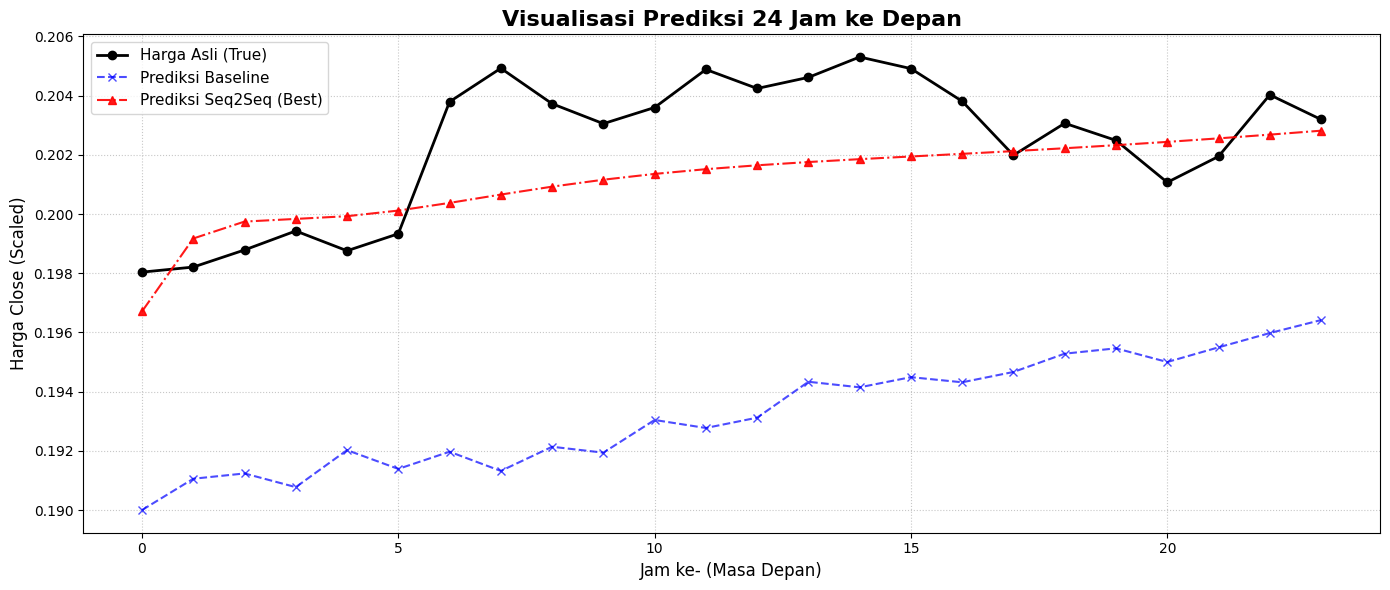



Tabel Detail Perbandingan Prediksi 24 Jam


,Harga Asli,Prediksi Baseline,Prediksi Seq2Seq (Best),Selisih
Jam ke-01,0.198038,0.190004,0.196709,0.001329
Jam ke-02,0.198209,0.191062,0.199173,0.000964
Jam ke-03,0.198786,0.191241,0.199745,0.000959
Jam ke-04,0.199428,0.190778,0.199835,0.000407
Jam ke-05,0.198759,0.192028,0.199927,0.001167
Jam ke-06,0.199333,0.191394,0.200116,0.000783
Jam ke-07,0.203789,0.191974,0.200375,0.003414
Jam ke-08,0.204922,0.191325,0.200657,0.004265
Jam ke-09,0.203724,0.192142,0.200924,0.002800
Jam ke-10,0.203051,0.191943,0.201158,0.001892


In [32]:
print("Melakukan inferensi prediksi pada sampel Data Test...\n")

for x_batch, y_batch in test_ds.take(1):
    x_sample = x_batch[:1]
    y_true_sample = y_batch[0].numpy()
    break

pred_base = baseline_loaded.predict(x_sample, verbose=0)[0]
pred_best_s2s = best_seq2seq_loaded.predict(x_sample, verbose=0)[0]

plt.figure(figsize=(14, 6))
plt.plot(y_true_sample, label="Harga Asli (True)", marker='o', color='black', linewidth=2)
plt.plot(pred_base, label="Prediksi Baseline", marker='x', color='blue', linestyle='--', alpha=0.7)
plt.plot(pred_best_s2s, label="Prediksi Seq2Seq (Best)", marker='^', color='red', linestyle='-.', alpha=0.9)

plt.title("Visualisasi Prediksi 24 Jam ke Depan", fontsize=16, fontweight='bold')
plt.xlabel("Jam ke- (Masa Depan)", fontsize=12)
plt.ylabel("Harga Close (Scaled)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()
print("\n")

selisih = np.abs(y_true_sample - pred_best_s2s)

table_data = {
    "Harga Asli": y_true_sample,
    "Prediksi Baseline": pred_base,
    "Prediksi Seq2Seq (Best)": pred_best_s2s,
    "Selisih": selisih
}

pred_df = pd.DataFrame(table_data)
pred_df.index = [f"Jam ke-{i+1:02d}" for i in range(24)]

print("Tabel Detail Perbandingan Prediksi 24 Jam")
display(pred_df)